# EDA Objective
Understand which claim, driver, accident, and vehicle characteristics are associated with successful subrogation opportunities, while identifying data quality issues, leakage risks, and modeling constraints.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("/Users/eugene/Desktop/Emory/Projects/Travelers/data/raw/Training_TriGuard.csv")
df.head()

,subrogation,claim_number,year_of_born,gender,email_or_tel_available,safety_rating,annual_income,high_education_ind,address_change_ind,living_status,...,claim_est_payout,vehicle_made_year,vehicle_category,vehicle_price,vehicle_color,vehicle_weight,age_of_DL,accident_type,in_network_bodyshop,vehicle_mileage
0,1.0,6090851,1990.0,F,0.0,75.0,70966.0,1.0,1.0,Rent,...,3218.84,2021.0,Large,16272.12725,red,21620.79697,25.0,multi_vehicle_clear,no,75421.0
1,0.0,4653734,1972.0,F,1.0,94.0,79723.0,1.0,1.0,Rent,...,1338.52,2025.0,Medium,34102.78197,silver,10840.58520,23.0,multi_vehicle_clear,yes,31988.0
2,0.0,1014777,2003.0,F,1.0,76.0,41527.0,1.0,1.0,Own,...,3540.05,2022.0,Compact,15000.00000,silver,24318.12282,23.0,multi_vehicle_unclear,yes,60876.0
3,1.0,8101873,1983.0,F,1.0,54.0,42099.0,1.0,1.0,Rent,...,1507.94,2025.0,Medium,16984.45295,white,36958.26656,23.0,multi_vehicle_unclear,yes,152772.0
4,0.0,5081870,1985.0,F,1.0,54.0,47206.0,1.0,1.0,Own,...,5080.63,2021.0,Compact,46545.72863,blue,11779.17422,17.0,multi_vehicle_clear,yes,41151.0


In [3]:
df.shape

(18001, 29)

In [4]:
# Target variable EDA
df["subrogation"].value_counts(normalize=True)

subrogation
0.0    0.771376
1.0    0.228624
Name: proportion, dtype: float64

In [5]:
df["claim_date"] = pd.to_datetime(df["claim_date"])
df.groupby(df["claim_date"].dt.to_period("M"))["subrogation"].mean()

claim_date
2015-01    0.230179
2015-02    0.240216
2015-03    0.213152
2015-04    0.243207
2015-05    0.228378
2015-06    0.229677
2015-07    0.209068
2015-08    0.229872
2015-09    0.229371
2015-10    0.217331
2015-11    0.241573
2015-12    0.233154
2016-01    0.239348
2016-02    0.232432
2016-03    0.240838
2016-04    0.206946
2016-05    0.224404
2016-06    0.218056
2016-07    0.216689
2016-08    0.248072
2016-09    0.204082
2016-10    0.219061
2016-11    0.231520
2016-12    0.258412
Freq: M, Name: subrogation, dtype: float64

In [6]:
monthly = df.groupby(
    df["claim_date"].dt.to_period("M")
)["subrogation"].agg(
    total_claims="count",
    subrogated_claims="sum",
    subrogation_rate="mean"
)
monthly

,total_claims,subrogated_claims,subrogation_rate
claim_date,,,
2015-01,782,180.0,0.230179
2015-02,741,178.0,0.240216
2015-03,882,188.0,0.213152
2015-04,736,179.0,0.243207
2015-05,740,169.0,0.228378
2015-06,775,178.0,0.229677
2015-07,794,166.0,0.209068
2015-08,857,197.0,0.229872
2015-09,715,164.0,0.229371


array([<Axes: xlabel='claim_date'>, <Axes: xlabel='claim_date'>],
      dtype=object)

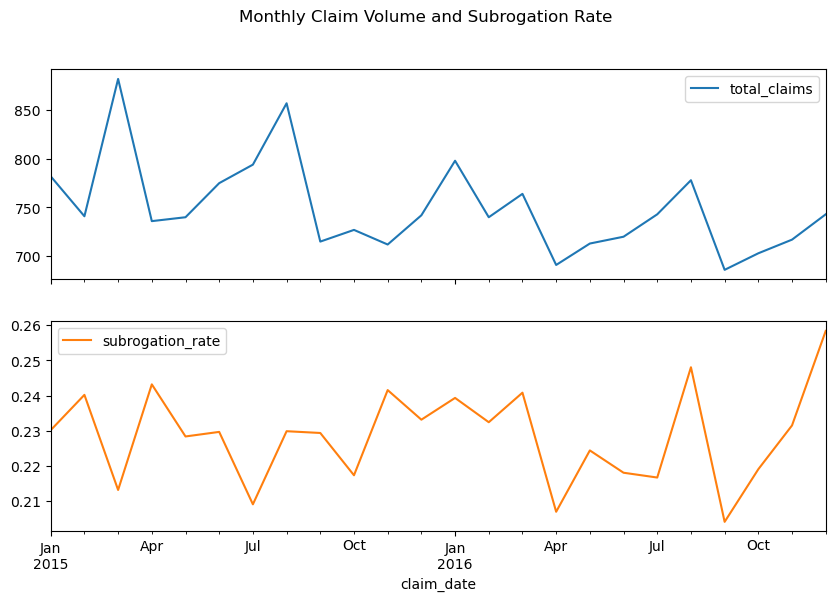

In [7]:
monthly[["total_claims", "subrogation_rate"]].plot(
    subplots=True, figsize=(10,6), title="Monthly Claim Volume and Subrogation Rate"
)


Monthly analysis of referred claims from 2015 to 2016 shows that both claim volumes and subrogation outcomes are relatively stable over time. The number of referred claims per month ranges from approximately 680 to 880, while subrogation success rates consistently fall between 20% and 26%. No sharp spikes or drops in either volume or recovery rates are observed, indicating a stable subrogation process without significant temporal disruptions or seasonality. This suggests that subrogation outcomes are primarily driven by claim-level characteristics rather than timing effects, supporting the use of a standard cross-sectional modeling approach.

In [22]:
numeric_vars = [
    "annual_income",
    "liab_prct",
    "claim_est_payout",
    "vehicle_price",
    "vehicle_mileage",
    "annual_income",
    "past_num_of_claims",
    "year_of_born"
]


In [24]:
df[numeric_vars].describe()

,annual_income,liab_prct,claim_est_payout,vehicle_price,vehicle_mileage,annual_income,past_num_of_claims,year_of_born
count,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000
mean,54587.451778,38.278278,3602.507022,30657.923288,80056.858111,54587.451778,3.634611,1980.770500
std,26287.598879,9.802537,3609.644983,20636.599225,30064.396369,26287.598879,5.603418,12.198355
min,30015.000000,0.000000,65.750000,15000.000000,500.000000,30015.000000,0.000000,1774.000000
25%,32193.500000,32.000000,1321.807500,15000.000000,59587.000000,32193.500000,0.000000,1973.000000
50%,46383.500000,38.000000,2414.370000,19637.231880,79765.000000,46383.500000,0.000000,1982.000000
75%,67397.000000,45.000000,4519.327500,42609.417130,100325.750000,67397.000000,6.000000,1990.000000
max,124993.000000,84.000000,21504.280000,130000.000000,188839.000000,124993.000000,43.000000,2008.000000


In [25]:
df[numeric_vars].isna().mean()

annual_income         0.000056
liab_prct             0.000056
claim_est_payout      0.000056
vehicle_price         0.000056
vehicle_mileage       0.000056
annual_income         0.000056
past_num_of_claims    0.000056
year_of_born          0.000056
dtype: float64

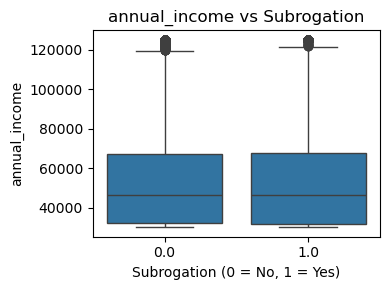

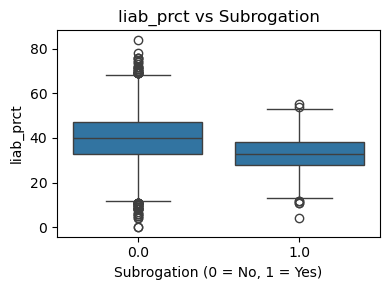

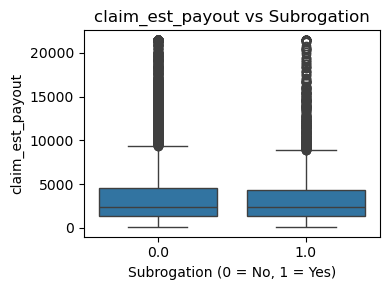

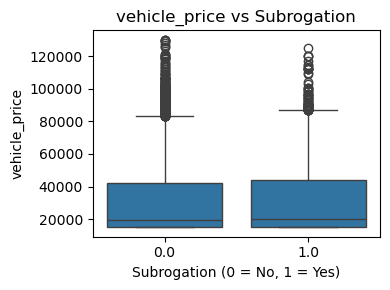

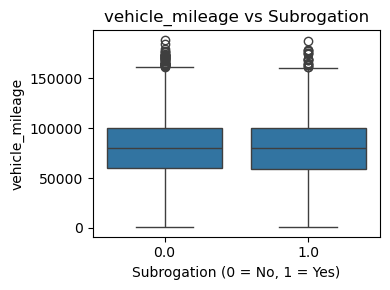

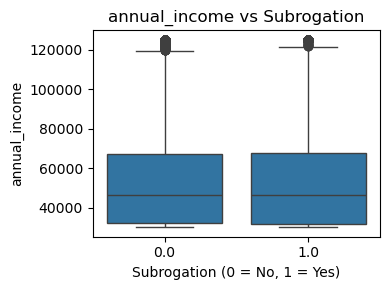

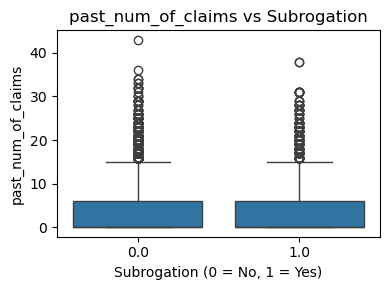

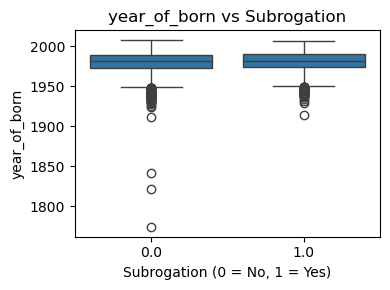

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

for var in numeric_vars:
    plt.figure(figsize=(4, 3))
    sns.boxplot(x="subrogation", y=var, data=df)
    plt.title(f"{var} vs Subrogation")
    plt.xlabel("Subrogation (0 = No, 1 = Yes)")
    plt.ylabel(var)
    plt.tight_layout()
    plt.show()

Exploratory analysis shows that liability percentage is the strongest numerical indicator of subrogation opportunity, with subrogated claims exhibiting significantly lower insured liability. Claim payout amount and vehicle value display modest positive association with subrogation likelihood, while demographic and historical variables such as income, mileage, and past claims show limited standalone discriminatory power. These results suggest that subrogation outcomes are primarily driven by accident-level responsibility rather than customer characteristics.